In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [ ]:
# 1. Load each CSV into its own DataFrame.
df_behavior = pd.read_csv(
    "../Data_Clean/EMA/Behaviour_new.csv"
)  # columns: user_id, anxious, calm, ...
df_class = pd.read_csv(
    "../Data_Clean/EMA/Class_new.csv"
)  # columns: user_id, course_id, ...
df_mood = pd.read_csv(
    "../Data_Clean/EMA/Mood_new.csv"
)  # columns: user_id, happy, sad, ...
df_stress = pd.read_csv(
    "../Data_Clean/EMA/Stress_new.csv"
)  # columns: user_id, level, ...
df_class2 = pd.read_csv("../Data_Clean/EMA/Class.csv")
df_event = pd.read_csv("../Data_Clean/EMA/Events.csv")
df_exercise = pd.read_csv("../Data_Clean/EMA/Exercise.csv")
df_sleep = pd.read_csv("../Data_Clean/EMA/Sleep.csv")
df_social = pd.read_csv("../Data_Clean/EMA/Social.csv")

In [43]:
# 1) Convert to pandas datetime (aware of UTC)
df_exercise["resp_time"] = pd.to_datetime(df_exercise["resp_time"], utc=True)

# 2) Create a new column with the Unix timestamp in seconds
df_exercise["datetime_utc"] = pd.to_datetime(
    df_exercise["resp_time"], unit="s", origin="unix"
)

# 2) Create a new column with the Unix timestamp in seconds
df_class2["resp_time"] = pd.to_datetime(df_class2["resp_time"], utc=True)
df_class2["datetime_utc"] = pd.to_datetime(
    df_class2["resp_time"], unit="s", origin="unix"
)

In [45]:
# order df1 to df9
dfs_list = [
    df_behavior,
    df_class,
    df_mood,
    df_stress,
    df_class2,
    df_event,
    df_exercise,
    df_sleep,
    df_social,
]

In [46]:
def weekly_aggregate_all_cols(
    df, user_col="user_id", time_col="datetime_utc", mean_cols=None
):
    """
    Aggregate each column of 'df' by (user_id, 1-week).
      - For columns in 'mean_cols': use mean.
      - For all other columns: use mode (taking the first if multiple).
    Keeps 'user_id' as the final index and 'datetime_utc' as a column.
    """
    if mean_cols is None:
        mean_cols = []

    # # 1) Ensure time_col is a proper datetime
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)

    # 2) Define a helper for mode (to avoid returning multiple values on ties)
    def first_mode(series):
        modes = series.mode(dropna=True)
        return modes.iloc[0] if len(modes) > 0 else np.nan

    # 3) Build the aggregation dict:
    #    - If col is in mean_cols => mean
    #    - Otherwise => mode
    agg_dict = {}
    for col in df.columns:
        if col in [user_col, time_col]:
            continue
        if col in mean_cols:
            agg_dict[col] = "mean"
        else:
            agg_dict[col] = first_mode

    # 4) Set the time as index, group by user_id, then resample weekly
    df = df.set_index(time_col)
    grouped = df.groupby(user_col, group_keys=False).resample("1W")

    # 5) Aggregate
    df_agg = grouped.agg(agg_dict)
    # 6) Right now 'df_agg' is a multi-index of [user_col, time_col].
    #    We'll reset only the time_col level so that user_col stays as the index.
    # df_agg.reset_index(level=time_col, inplace=True)

    # # 7) Rename the time_col for clarity
    # df_agg.rename(columns={time_col: 'datetime_utc'}, inplace=True)
    df_agg.reset_index(inplace=True)
    df_agg.rename(columns={time_col: "datetime_utc", user_col: "user_id"}, inplace=True)

    #    At this point:
    #      - The index is user_col
    #      - We have a column named 'datetime_utc'
    #      - The other columns are the aggregated columns
    return df_agg

In [47]:
weekly_dfs = []
mean_columns = []

# Add 'userid' column for consistency
for df in dfs_list:
    df["userid"] = df["user_id"]

# Weekly aggregation
for i, df in enumerate(dfs_list):
    if "datetime_utc" not in df.columns:
        print(f"Skipping df index {i} - missing 'datetime_utc'")
        continue
    df_weekly = weekly_aggregate_all_cols(
        df, user_col="user_id", time_col="datetime_utc", mean_cols=mean_columns
    )
    weekly_dfs.append(df_weekly)

# Drop missing values after aggregation
for df in weekly_dfs:
    df.dropna(inplace=True)

# List of all weekly-aggregated DataFrames
dfs_list = [
    df_behavior,
    df_class,
    df_mood,
    df_stress,
    df_class2,
    df_event,
    df_exercise,
    df_sleep,
    df_social,
]


# Merge all on user_id and datetime_utc
def merge_many_on_user_time(dfs):
    if not dfs:
        return pd.DataFrame()
    merged = dfs[0].copy()
    for i in range(1, len(dfs)):
        merged = pd.merge(
            merged,
            dfs[i],
            on=["user_id", "datetime_utc"],
            how="outer",
            suffixes=("", f"_df{i}"),
        )
    return merged


df_combined = merge_many_on_user_time(dfs_list)

display(df_combined.head())

,user_id,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,...,resp_time_df7,sleep_hours,sleep_quality,sleepiness,location_df7,userid_df7,resp_time_df8,number,location_df8,userid_df8
0,u00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,u00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,u00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,u00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,u00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
# import pandas as pd

# # List of your DataFrames
# dfs_list = [df_behavior, df_class, df_mood, df_stress, df_class2,
#             df_event, df_exercise, df_sleep, df_social]

# # Ensure that each DataFrame's 'datetime_utc' column is in datetime format with UTC
# for i, df in enumerate(dfs_list):
#     if 'datetime_utc' in df.columns:
#         dfs_list[i]['datetime_utc'] = pd.to_datetime(df['datetime_utc'], errors='coerce', utc=True)
#     else:
#         print(f"DataFrame at index {i} does not have a 'datetime_utc' column")

# # Define the merging function on 'user_id' and 'datetime_utc'
# def merge_many_on_user_time(dfs):
#     if not dfs:
#         return pd.DataFrame()
#     merged = dfs[0].copy()
#     for i in range(1, len(dfs)):
#         merged = pd.merge(
#             merged,
#             dfs[i],
#             on=["user_id", "datetime_utc"],
#             how="outer",
#             suffixes=("", f"_df{i}")
#         )
#     return merged

# # Perform the merge
# df_combined = merge_many_on_user_time(dfs_list)


# df_combined.head()

In [49]:
print(df_combined.shape)

(8852, 70)


In [50]:
# Print na values if they are more less than 8700

na_counts = df_combined.isna().sum()
print(na_counts[na_counts > 8500])

happy                   8576
happyornot              8580
location_df2            8576
resp_time_df2           8576
sad                     8576
sadornot                8585
userid_df2              8576
resp_time_df5           8620
positive_event_score    8620
negative_event_score    8620
emotion_range           8620
has_positive_text       8620
has_negative_text       8620
positive_text           8677
negative_text           8693
location_df5            8620
userid_df5              8620
latitude                8523
longitude               8523
dtype: int64


In [51]:
print(df_combined.isna().sum())

user_id             0
anxious          8398
calm             8407
conventional     8416
critical         8398
                 ... 
userid_df7       7205
resp_time_df8    7436
number           7681
location_df8     7681
userid_df8       7436
Length: 70, dtype: int64


In [52]:
feature_cols = [
    "anxious",
    "calm",
    "conventional",
    "critical",
    "dependable",
    "disorganized",
    "enthusiastic",
    "experiences",
    "reserved",
    "sympathetic",
    "due",
    "experience",
    "hours",
    "happy",
    "happyornot",
    "sad",
    "sadornot",
    "level",
    "positive_event_score",
    "negative_event_score",
    "emotion_range",
    "has_positive_text",
    "has_negative_text",
    "positive_text",
    "negative_text",
    "weekday",
    "hour",
    "exercise",
    "walk",
    "have",
    "schedule",
    "sleep_hours",
    "sleep_quality",
    "sleepiness",
    "number",
    "user_id",
    "datetime_utc",
]

In [53]:
# min_non_missing = len(feature_cols) - 20

# # drop rows that do not have at least more than 5 missing vals
# df_final = df_combined.dropna(subset=feature_cols, thresh=min_non_missing)

df_final = df_combined[feature_cols].sort_values(["user_id", "datetime_utc"])

# perform a forward fill and then a backward fill within each user_id group.
df_final_filled = df_final.groupby("user_id", group_keys=False).apply(
    lambda group: group.ffill().bfill()
)

print(df_final_filled.shape)

(8852, 37)


/var/folders/f4/vybgzbbx1sg165hn_kn98j0m0000gn/T/ipykernel_4608/183797323.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda group: group.ffill().bfill()
/var/folders/f4/vybgzbbx1sg165hn_kn98j0m0000gn/T/ipykernel_4608/183797323.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_final_filled = df_final.groupby("user_id", group_keys=False).apply(


In [54]:
df_final_filled.dropna(inplace=True)
# df_final_filled.to_csv("df_final_filled.csv")

In [55]:
df_final_filled.shape

(6550, 37)

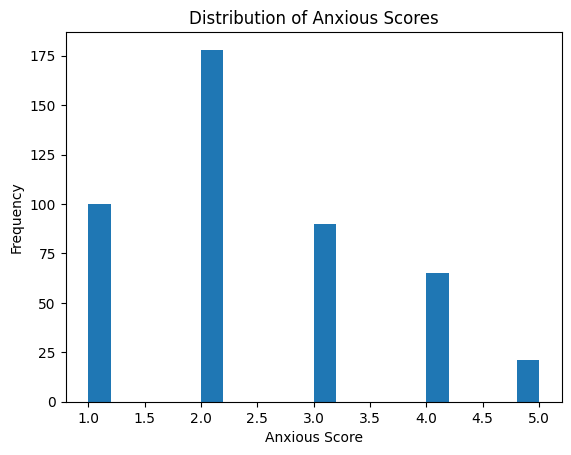

In [56]:
# Plotting Distribution of Anxious Scores
plt.hist(df_combined["anxious"].dropna(), bins=20)
plt.xlabel("Anxious Score")
plt.ylabel("Frequency")
plt.title("Distribution of Anxious Scores")
plt.show()

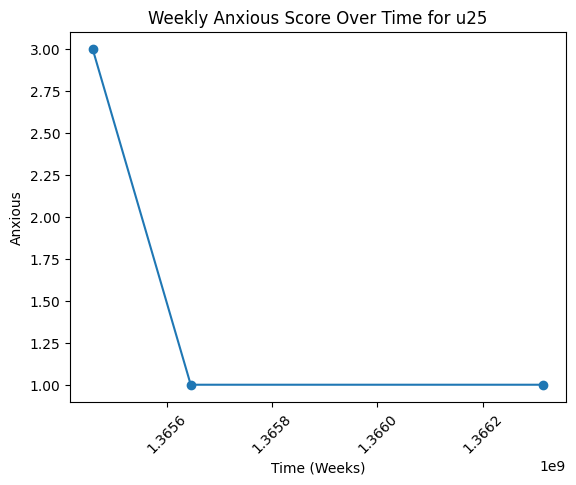

In [57]:
user_of_interest = "u25"
df_u25 = df_combined[df_combined["user_id"] == user_of_interest].sort_values(
    "resp_time"
)

plt.plot(df_u25["resp_time"], df_u25["anxious"], marker="o")
plt.xlabel("Time (Weeks)")
plt.ylabel("Anxious")
plt.title(f"Weekly Anxious Score Over Time for {user_of_interest}")
plt.xticks(rotation=45)
plt.show()

In [58]:
# Example: Merge df_depression
df_depression = pd.read_csv(
    "https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/cleaned_data/surveys/clean_PHQ-9.csv"
)
df_depression.rename(columns={"uid": "user_id"}, inplace=True)
df_combined_final = df_final_filled.merge(df_depression, on=["user_id"], how="inner")

In [59]:
df_combined_final.columns

Index(['anxious', 'calm', 'conventional', 'critical', 'dependable',
       'disorganized', 'enthusiastic', 'experiences', 'reserved',
       'sympathetic', 'due', 'experience', 'hours', 'happy', 'happyornot',
       'sad', 'sadornot', 'level', 'positive_event_score',
       'negative_event_score', 'emotion_range', 'has_positive_text',
       'has_negative_text', 'positive_text', 'negative_text', 'weekday',
       'hour', 'exercise', 'walk', 'have', 'schedule', 'sleep_hours',
       'sleep_quality', 'sleepiness', 'number', 'user_id', 'datetime_utc',
       'type', 'Little interest or pleasure in doing things',
       'Feeling down, depressed, hopeless.',
       'Trouble falling or staying asleep, or sleeping too much.',
       'Feeling tired or having little energy', 'Poor appetite or overeating',
       'Feeling bad about yourself or that you are a failure or have let yourself or your family down',
       'Trouble concentrating on things, such as reading the newspaper or watching telev

In [60]:
df_combined_final.shape

(12645, 50)

In [61]:
feature_cols = [
    "anxious",
    "calm",
    "conventional",
    "critical",
    "dependable",
    "disorganized",
    "enthusiastic",
    "experiences",
    "reserved",
    "sympathetic",
    "due",
    "experience",
    "hours",
    "happy",
    "happyornot",
    "sad",
    "sadornot",
    "level",
    "positive_event_score",
    "negative_event_score",
    "emotion_range",
    "has_positive_text",
    "has_negative_text",
    "positive_text",
    "negative_text",
    "weekday",
    "hour",
    "exercise",
    "walk",
    "have",
    "schedule",
    "sleep_hours",
    "sleep_quality",
    "sleepiness",
    "number",
]

In [62]:
df_combined_final.head()

,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,sympathetic,...,"Trouble falling or staying asleep, or sleeping too much.",Feeling tired or having little energy,Poor appetite or overeating,Feeling bad about yourself or that you are a failure or have let yourself or your family down,"Trouble concentrating on things, such as reading the newspaper or watching television",Moving or speaking so slowly that other people could have noticed. Or the opposite being so figety or restless that you have been moving around a lot more than usual,"Thoughts that you would be better off dead, or of hurting yourself",Response,total_score,depression_severity
0,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,0,1,0,0,0,0,0,0,2,Minimal depression
1,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,0,1,0,1,1,0,0,1,3,Minimal depression
2,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,0,1,0,0,0,0,0,0,2,Minimal depression
3,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,0,1,0,1,1,0,0,1,3,Minimal depression
4,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,0,1,0,0,0,0,0,0,2,Minimal depression


In [63]:
df_combined_final["experience"].value_counts()

experience
3.0    5476
1.0    4456
2.0    1414
4.0    1098
5.0     201
Name: count, dtype: int64

In [64]:
df_combined_final[feature_cols].isna().sum()

anxious                 0
calm                    0
conventional            0
critical                0
dependable              0
disorganized            0
enthusiastic            0
experiences             0
reserved                0
sympathetic             0
due                     0
experience              0
hours                   0
happy                   0
happyornot              0
sad                     0
sadornot                0
level                   0
positive_event_score    0
negative_event_score    0
emotion_range           0
has_positive_text       0
has_negative_text       0
positive_text           0
negative_text           0
weekday                 0
hour                    0
exercise                0
walk                    0
have                    0
schedule                0
sleep_hours             0
sleep_quality           0
sleepiness              0
number                  0
dtype: int64

In [65]:
# df_final = df_final.sort_values(['user_id', 'datetime_utc'])

# # perform a forward fill and then a backward fill within each user_id group.
# df_final_filled = df_final.groupby('user_id', group_keys=False).apply(lambda group: group.ffill().bfill())

In [66]:
# df_final_filled.bfill(inplace=True)

In [67]:
# ordinal_cols = [
#     "anxious", "calm", "conventional", "enthusiastic", "reserved",
#     "critical", "sympathetic", "dependable", "disorganized", "experiences"
# ]

# now just do ordinal encoding of these columns
# from sklearn.preprocessing import OrdinalEncoder

# encoder = OrdinalEncoder()
# df_combined_final[feature_cols] = encoder.fit_transform(df_combined_final[feature_cols])

In [68]:
df_combined_final["level"].value_counts()

level
1.0    5306
4.0    2576
2.0    2391
3.0    1648
5.0     724
Name: count, dtype: int64

In [69]:
df_combined_final["experience"].value_counts()

experience
3.0    5476
1.0    4456
2.0    1414
4.0    1098
5.0     201
Name: count, dtype: int64

In [70]:
# change mapping of values for experience and stress level

# Create the mapping dictionary
mapping = {1: 3, 2: 1, 3: 2, 4: 4, 5: 5}

# Apply the mapping to the 'experience' column
df_combined_final["experience"] = df_combined_final["experience"].map(mapping)

mapping_level = {1: 3, 2: 2, 3: 1, 4: 4, 5: 5}

# Apply the mapping to the "level" column
df_combined_final["level"] = df_combined_final["level"].map(mapping_level)

In [71]:
df_combined_final.weekday

0          Monday
1          Monday
2          Monday
3          Monday
4          Monday
           ...   
12640    Thursday
12641    Thursday
12642    Thursday
12643    Thursday
12644    Thursday
Name: weekday, Length: 12645, dtype: object

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

final_features = [
    "anxious",
    "calm",
    "conventional",
    "critical",
    "dependable",
    "disorganized",
    "enthusiastic",
    "experiences",
    "reserved",
    "sympathetic",
    "due",
    "experience",
    "hours",
    "happy",
    "happyornot",
    "sad",
    "sadornot",
    "level",
    "positive_event_score",
    "negative_event_score",
    "emotion_range",
    "has_positive_text",
    "has_negative_text",
    "hour",
    "exercise",
    "walk",
    "have",
    "schedule",
    "sleep_hours",
    "sleep_quality",
    "sleepiness",
    "number",
]
X = df_combined_final[final_features].copy()
y = df_combined_final["total_score"].copy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit a simple linear regression
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predictions
y_pred = reg.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R^2:", r2)

MSE: 16.557767868661177
R^2: 0.3705212973648856


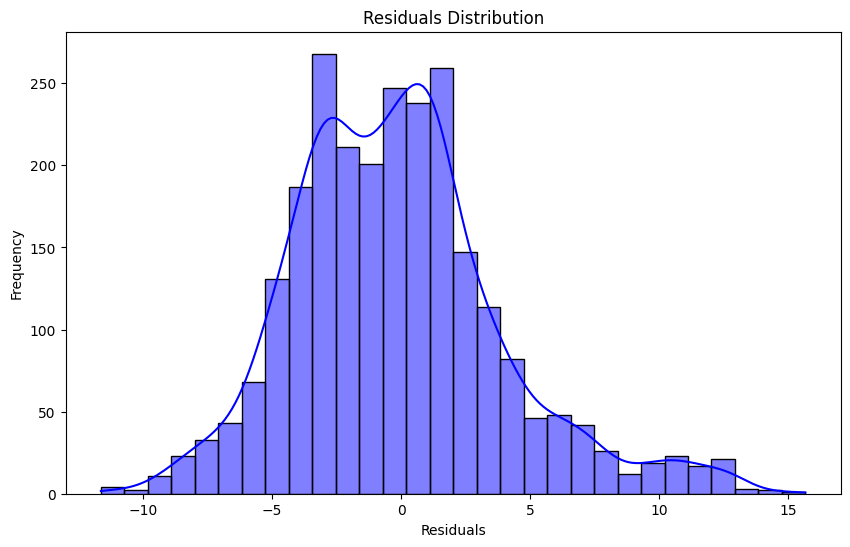

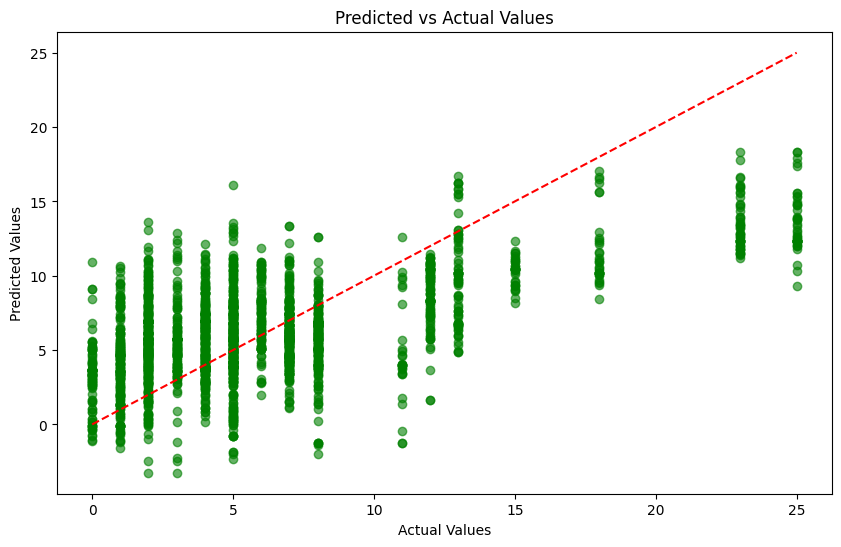

Shapiro-Wilk Test: Test Statistic = 0.9713713526725769, p-value = 4.433446250085124e-22
D'Agostino and Pearson's Test: Test Statistic = 201.59405518943498, p-value = 1.6765137642830603e-44


In [73]:
import seaborn as sns
import numpy as np
from scipy.stats import shapiro, normaltest

import matplotlib.pyplot as plt

# Residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color="blue")
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Scatter plot of predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="green")
plt.plot(
    [min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--"
)
plt.title("Predicted vs Actual Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

# Statistical analysis

# Shapiro-Wilk test for normality of residuals
shapiro_test_stat, shapiro_p_value = shapiro(residuals)
print(
    f"Shapiro-Wilk Test: Test Statistic = {shapiro_test_stat}, p-value = {shapiro_p_value}"
)

# D'Agostino and Pearson's test for normality of residuals
dagostino_test_stat, dagostino_p_value = normaltest(residuals)
print(
    f"D'Agostino and Pearson's Test: Test Statistic = {dagostino_test_stat}, p-value = {dagostino_p_value}"
)

In [74]:
X.head()

,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,sympathetic,...,has_negative_text,hour,exercise,walk,have,schedule,sleep_hours,sleep_quality,sleepiness,number
0,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,1.0,14.0,3.0,2.0,2.0,1.0,8.0,1.0,1.0,5.0
1,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,1.0,14.0,3.0,2.0,2.0,1.0,8.0,1.0,1.0,5.0
2,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,1.0,14.0,3.0,2.0,2.0,1.0,8.0,1.0,1.0,5.0
3,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,1.0,14.0,3.0,2.0,2.0,1.0,8.0,1.0,1.0,5.0
4,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,1.0,14.0,3.0,2.0,2.0,1.0,8.0,1.0,1.0,5.0


In [75]:
X.columns

Index(['anxious', 'calm', 'conventional', 'critical', 'dependable',
       'disorganized', 'enthusiastic', 'experiences', 'reserved',
       'sympathetic', 'due', 'experience', 'hours', 'happy', 'happyornot',
       'sad', 'sadornot', 'level', 'positive_event_score',
       'negative_event_score', 'emotion_range', 'has_positive_text',
       'has_negative_text', 'hour', 'exercise', 'walk', 'have', 'schedule',
       'sleep_hours', 'sleep_quality', 'sleepiness', 'number'],
      dtype='object')

In [76]:
# X.drop(columns=["const"], inplace=True)

# 3) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Set up XGB and param grid
xgb_model = XGBRegressor(objective="reg:squarederror", random_state=42)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    verbose=1,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score (neg MSE):", grid_search.best_score_)

# 5) Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Test MSE:", mse)
print("Test R^2:", r2)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best CV score (neg MSE): -3.1105285752012497
Test MSE: 3.0470660907476526
Test R^2: 0.8841593265533447


In [77]:
X.head()

,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,sympathetic,...,has_negative_text,hour,exercise,walk,have,schedule,sleep_hours,sleep_quality,sleepiness,number
0,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,1.0,14.0,3.0,2.0,2.0,1.0,8.0,1.0,1.0,5.0
1,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,1.0,14.0,3.0,2.0,2.0,1.0,8.0,1.0,1.0,5.0
2,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,1.0,14.0,3.0,2.0,2.0,1.0,8.0,1.0,1.0,5.0
3,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,1.0,14.0,3.0,2.0,2.0,1.0,8.0,1.0,1.0,5.0
4,4.0,4.0,5.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0,...,1.0,14.0,3.0,2.0,2.0,1.0,8.0,1.0,1.0,5.0


In [78]:
X.columns

Index(['anxious', 'calm', 'conventional', 'critical', 'dependable',
       'disorganized', 'enthusiastic', 'experiences', 'reserved',
       'sympathetic', 'due', 'experience', 'hours', 'happy', 'happyornot',
       'sad', 'sadornot', 'level', 'positive_event_score',
       'negative_event_score', 'emotion_range', 'has_positive_text',
       'has_negative_text', 'hour', 'exercise', 'walk', 'have', 'schedule',
       'sleep_hours', 'sleep_quality', 'sleepiness', 'number'],
      dtype='object')

In [79]:
import pickle

# Get best hyperparameters from grid search
best_params = grid_search.best_params_

# Retrain on full data using best params
final_model = XGBRegressor(objective="reg:squarederror", random_state=42, **best_params)

final_model.fit(X, y)

# 8) Save the trained model as a pickle file
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Final model retrained on full data and saved as 'xgb_final_model.pkl'")

Final model retrained on full data and saved as 'xgb_final_model.pkl'


In [81]:
##############################
# 1) Example: Ordinary Least Squares (OLS)
##############################

# Suppose your DataFrame is called df:
#  - df["depression_score"] is numeric from 0–25
#  - the other columns are your predictors

# Define predictor columns
feature_cols = [
    "anxious",
    "calm",
    "conventional",
    "critical",
    "dependable",
    "disorganized",
    "enthusiastic",
    "experiences",
    "reserved",
    "sympathetic",
    "due",
    "experience",
    "hours",
    "happy",
    "happyornot",
    "sad",
    "sadornot",
    "level",
    "positive_event_score",
    "negative_event_score",
    "emotion_range",
    "has_positive_text",
    "has_negative_text",
    "hour",
    "exercise",
    "walk",
    "have",
    "schedule",
    "sleep_hours",
    "sleep_quality",
    "sleepiness",
    "number",
]

# Build a formula string for OLS
formula_ols = "total_score ~ " + " + ".join(feature_cols)

# Fit the OLS model
model_ols = smf.ols(formula=formula_ols, data=df_combined_final).fit()

print("=== OLS Regression Results ===")
print(model_ols.summary())

# Interpretation:
# - The 'coef' column under each predictor shows how a one-unit change
#   in that predictor is associated with a change in depression_score,
#   controlling for the other predictors.
# - The p-values (P>|t|) show which predictors are statistically significant
# - R-squared shows how much variance is explained, and the F-statistic
#   tests if all predictors jointly have some explanatory power.

=== OLS Regression Results ===
                            OLS Regression Results                            
Dep. Variable:            total_score   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     255.6
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        01:50:20   Log-Likelihood:                -35998.
No. Observations:               12645   AIC:                         7.206e+04
Df Residuals:                   12613   BIC:                         7.230e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
I

after removing happy from variables.
The key differences from the previous results are minimal:
	•	R-squared went from ~0.251 to ~0.250, essentially unchanged.
	•	Adjusted R-squared remains ~0.232.
	•	AIC went from ~3722 to ~3721 – a tiny (and likely negligible) improvement.

Overall, removing happy didn’t make the model “worse,” but it also didn’t materially improve fit or significantly alter the other coefficients. You may have removed some mild collinearity, but from a performance perspective, the difference is very slight.

1. Model Fit (High-Level)
	•	R-squared = 0.250
About 25% of the variance in depression score is explained.
	•	Adjusted R-squared = 0.232
Similar to the original model, meaning the set of predictors collectively explains ~23% once adjusted for the number of predictors.
	•	F-statistic = 13.62, p ≈ 5.63e-30
Highly significant overall. The set of 15 predictors still offers explanatory power for depression scores.

2. Key Significant Predictors
	1.	anxious (coef = +1.34, p = 0.003)
	•	A one‐point increase in “anxious” is associated with a ~+1.34 rise in total_score (holding others constant).
	2.	conventional (−2.19, p < 0.0001)
	•	More conventional → about 2.19 points lower depression score.
	3.	dependable (−1.56, p < 0.0001)
	•	More dependable → about 1.56 points lower depression score.
	4.	reserved (+1.22, p < 0.001)
	•	More reserved → about +1.22 in depression score.
	5.	sympathetic (+1.01, p = 0.031)
	•	More sympathetic → about +1.01 in depression score.
	6.	sad (+3.48, p < 0.0001)
	•	This remains the largest positive effect: each unit increase in “sad” → +3.48 points.
	7.	experience (+0.81, p = 0.009)
	•	More “experience” → ~+0.81 in depression score.

These effects are similar to before: sad remains the strongest positive predictor, while being conventional or dependable strongly lowers the predicted depression score.

3. Borderline or Non-Significant
	•	calm (p = 0.104)
	•	due (p = 0.076)
	•	critical, disorganized, enthusiastic, experiences (plural), level, hours – all > 0.05, suggesting they’re not statistically different from zero once controlling for the others.


In [82]:
##############################
# 2) Example: Generalized Linear Model (GLM) with Gaussian + Identity
##############################

# The same model in GLM form:
formula_glm = "total_score ~ " + " + ".join(feature_cols)

# Fit a GLM with Gaussian family, identity link
model_glm = smf.glm(
    formula=formula_glm,
    data=df_combined_final,
    family=sm.families.Gaussian(sm.families.links.identity()),
).fit()

print("\n=== GLM (Gaussian, Identity) Results ===")
print(model_glm.summary())

# Interpretation:
# - This is nearly identical to OLS in practice.
# - The 'coef' estimates, standard errors, etc. are interpreted similarly.
# - The difference is conceptual: GLM is part of a broader family.
#   For a roughly normal outcome (0–25 scale), this is fine.

##############################
# 3) Possible Alternative Models
##############################
# (No direct code below, just notes)

# - Ordinal Logistic/Probit Regression:
#   If you treat 'depression_score' (0–25) as ordinal categories
#   rather than truly continuous, you might prefer an ordinal model.
#   In Python, statsmodels has:
#     from statsmodels.miscmodels.ordinal_model import OrderedModel
#   But interpretability can be more complex (log-odds or threshold parameters).
#
# - Robust Regression:
#   If you have outliers or non-normal residuals, you could consider robust methods:
#     from statsmodels.robust.robust_linear_model import RLM
#
# - Non-parametric approaches:
#   If you suspect strong non-linearity or weird distribution, you might do
#   random forests, gradient boosting, or other machine-learning models,
#   though they won't provide the same straightforward coefficient-based inference.


=== GLM (Gaussian, Identity) Results ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:            total_score   No. Observations:                12645
Model:                            GLM   Df Residuals:                    12613
Model Family:                Gaussian   Df Model:                           31
Link Function:               identity   Scale:                          17.430
Method:                          IRLS   Log-Likelihood:                -35998.
Date:                Wed, 30 Apr 2025   Deviance:                   2.1985e+05
Time:                        01:50:20   Pearson chi2:                 2.20e+05
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4656
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(


Significant Variables: “sad,” “anxious,” “reserved,” “sympathetic,” “experience,” “conventional,” and “dependable” – the same set that emerged in OLS.

Model Performance: Captures roughly 25–28% of variance (moderate) – typical in psychological/behavioral contexts.

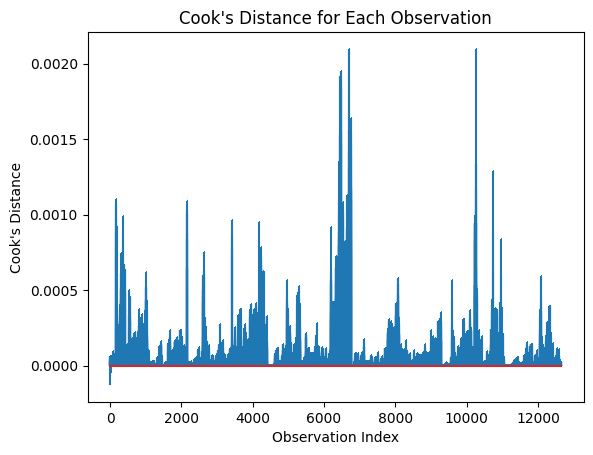

Potentially influential points (Cook's D > 4/n): [  170   174   175   176   177   178   179   180   181   270   272   274
   282   284   286   288   290   300   302   303   304   305   306   307
   308   309   310   311   312   313   314   315   316   317   318   319
   320   321   322   323   324   325   326   327   328   329   330   331
   332   333   334   335   348   350   351   352   353   354   355   356
   357   358   359   360   362   363   364   368   369   384   385   386
   387   388   404   405   406   407   408   409   410   411   540   541
   543   544   545   546   547   548   549   806   864   866   868   870
   882   968  1000  1001  1002  1004  1006  1008  1010  1012  1014  1016
  1018  1020  1022  1024  1026  2153  2154  2155  2156  2157  2159  2160
  2161  2162  2163  2164  2165  2598  2600  2602  2604  2606  2608  2610
  2612  2614  2616  2618  2620  2622  2624  2626  2628  3412  3414  3416
  3418  3420  3586  3588  3656  3658  3660  3924  3926  3932  3936  3938
  

In [83]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


influence = model_ols.get_influence()
cooks_d, pvals = influence.cooks_distance

# Let's plot Cook's distance:
fig, ax = plt.subplots()
ax.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
ax.set_xlabel("Observation Index")
ax.set_ylabel("Cook's Distance")
plt.title("Cook's Distance for Each Observation")
plt.show()

# There's no absolute cutoff, but a rule-of-thumb is any Cook’s D above ~4/n
# (where n is number of observations) might be particularly influential.
n = len(X)
threshold = 4 / n
potential_outliers = np.where(cooks_d > threshold)[0]
print("Potentially influential points (Cook's D > 4/n):", potential_outliers)

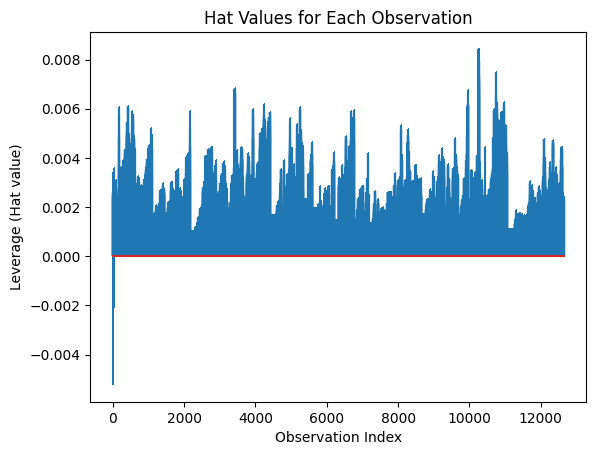

Points with high leverage (hat values): [  174   175   176   177   404   405   406   407   408   409   410   411
   416   417   418   419   420   421   422   423   540   541   550   551
   560   561   562   563   564   565   566   567   568   569  1082  1083
  2157  2163  2164  2165  3411  3412  3413  3414  3415  3416  3417  3418
  3419  3420  3933  3934  3935  3936  3937  3938  3939  3940  3941  3942
  4173  4174  4235  4236  4237  4238  4239  4240  4241  4242  4243  4244
  4245  4246  4247  4248  4249  4250  4251  4252  4253  4254  4255  4256
  4257  4258  4259  4260  4261  4262  4263  4264  4347  4348  4349  4350
  4351  4352  4379  4380  4381  4382  4383  4384  4385  4386  4387  4388
  4389  4390  4391  4392  4393  4394  4395  4396  4397  4398  4399  4400
  4401  4402  4403  4404  4409  4410  4965  4966  4967  4968  5175  5176
  5177  5178  5251  5252  5253  5254  5255  5256  5257  5258  5269  5270
  5277  5278  6687  6688  6701  6702  6705  6706  6707  6708  6721  6722
  6723  672

In [84]:
hat_vals = influence.hat_matrix_diag
fig, ax = plt.subplots()
ax.stem(np.arange(len(hat_vals)), hat_vals, markerfmt=",")
ax.set_xlabel("Observation Index")
ax.set_ylabel("Leverage (Hat value)")
plt.title("Hat Values for Each Observation")
plt.show()

# Typically, a rule-of-thumb cutoff is 2*(p+1)/n
# (where p is # of predictors, n is # of observations).
p = X.shape[1] - 1  # minus 1 because we added the constant
leverage_cutoff = 2 * (p + 1) / n
potential_high_leverage = np.where(hat_vals > leverage_cutoff)[0]
print("Points with high leverage (hat values):", potential_high_leverage)

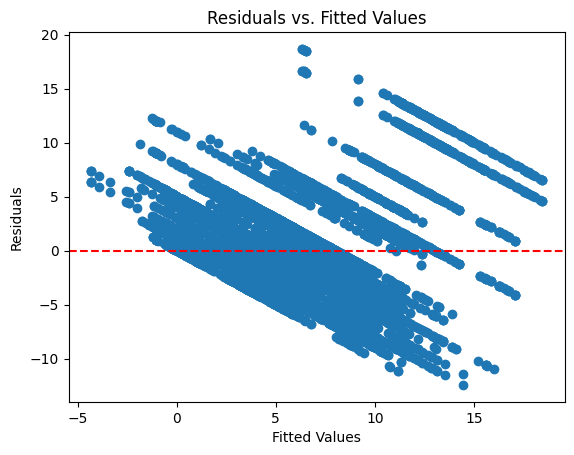

In [85]:
import statsmodels.api as sm

fig, ax = plt.subplots()
ax.scatter(model_ols.fittedvalues, model_ols.resid)
ax.axhline(y=0, color="red", linestyle="--")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.show()

# we see a curved pattern or funnel shape, it indicates
# potential non-linearity or heteroscedasticity.

In [86]:
feature_cols

['anxious',
 'calm',
 'conventional',
 'critical',
 'dependable',
 'disorganized',
 'enthusiastic',
 'experiences',
 'reserved',
 'sympathetic',
 'due',
 'experience',
 'hours',
 'happy',
 'happyornot',
 'sad',
 'sadornot',
 'level',
 'positive_event_score',
 'negative_event_score',
 'emotion_range',
 'has_positive_text',
 'has_negative_text',
 'hour',
 'exercise',
 'walk',
 'have',
 'schedule',
 'sleep_hours',
 'sleep_quality',
 'sleepiness',
 'number']

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/sandbox/regression/predstd.py:97: RuntimeWarning: invalid value encountered in sqrt
  predstd = np.sqrt(predvar)


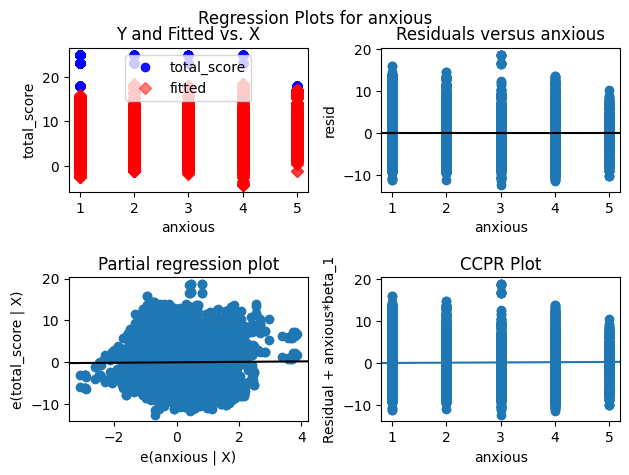

In [87]:
import statsmodels.graphics.regressionplots as sgm

# E.g., let's see partial regression for "calm"
sgm.plot_regress_exog(model_ols, "anxious")
plt.show()

# This creates 4 subplots:
# 1) partial regression plot for calm
# 2) residuals vs. calm
# 3) ...
# and so forth.
#
# Look at the partial regression plot to see if there's any curvature.

In [88]:
df_combined["anx_sq"] = df_combined["anxious"] ** 2

# Then re-run the regression:
X = df_combined_final[feature_cols]
X = sm.add_constant(X)
model_poly = sm.OLS(y, X).fit()
print(model_poly.summary())

                            OLS Regression Results                            
Dep. Variable:            total_score   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     255.6
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        01:50:22   Log-Likelihood:                -35997.
No. Observations:               12645   AIC:                         7.206e+04
Df Residuals:                   12613   BIC:                         7.230e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    8.7023 

In [89]:
import statsmodels.formula.api as smf
import patsy

# Using a spline basis for 'sad', for instance


formula_spline = "total_score ~ bs(sad, df=3) + anxious + conventional + dependable + sad + calm + critical + disorganized + enthusiastic + experiences + reserved + sympathetic + level + due + experience + hours"


formula_glm = "total_score ~ " + " + ".join(feature_cols)


model_spline = smf.ols(formula_spline, data=df_combined_final).fit()
print(model_spline.summary())

                            OLS Regression Results                            
Dep. Variable:            total_score   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     160.1
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        01:50:22   Log-Likelihood:                -37780.
No. Observations:               12645   AIC:                         7.560e+04
Df Residuals:                   12626   BIC:                         7.574e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -8.822e+10   1.04e+11  

In [90]:
# removing non- significant variables
# critical, disorganized, enthusiastic, experiences (plural), level, hours
import statsmodels.formula.api as smf
import patsy

# Using a spline basis for 'sad', for instance


formula_spline = "total_score ~ bs(sad, df=3) + anxious + conventional + dependable + sad + calm + reserved + sympathetic + due + experience"


formula_glm = "total_score ~ " + " + ".join(feature_cols)


model_spline = smf.ols(formula_spline, data=df_combined_final).fit()
print(model_spline.summary())

                            OLS Regression Results                            
Dep. Variable:            total_score   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     215.5
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        01:50:22   Log-Likelihood:                -37902.
No. Observations:               12645   AIC:                         7.583e+04
Df Residuals:                   12632   BIC:                         7.593e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -6.743e+10   1.05e+11  

### Refit Modell Without Outliers

In [ ]:
# refit both models without outliers
df_no_outliers = df_combined_final.drop(index=potential_outliers)

print("Original df shape:", df_combined_final.shape)
print("After dropping outliers:", df_no_outliers.shape)

Original df shape: (12645, 50)
After dropping outliers: (11751, 50)


In [92]:
# Rebuild X and y from df_no_outliers
X_no_outliers = df_no_outliers[feature_cols]  # etc.
y_no_outliers = df_no_outliers["total_score"]

X_no_outliers = sm.add_constant(X_no_outliers)
model_ols_no_outliers = sm.OLS(y_no_outliers, X_no_outliers).fit()

print("=== OLS Results without Outliers ===")
print(model_ols_no_outliers.summary())

=== OLS Results without Outliers ===
                            OLS Regression Results                            
Dep. Variable:            total_score   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     247.9
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        01:50:22   Log-Likelihood:                -29838.
No. Observations:               11751   AIC:                         5.974e+04
Df Residuals:                   11719   BIC:                         5.998e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [93]:
# The same model in GLM form:
formula_glm = "total_score ~ " + " + ".join(feature_cols)

# Fit a GLM with Gaussian family, identity link
model_glm_no_outliers = smf.glm(
    formula=formula_glm,
    data=df_no_outliers,
    family=sm.families.Gaussian(sm.families.links.identity()),
).fit()

print("\n=== GLM (Gaussian, Identity) Results WITHOUT Outliers ===")
print(model_glm_no_outliers.summary())


=== GLM (Gaussian, Identity) Results WITHOUT Outliers ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:            total_score   No. Observations:                11751
Model:                            GLM   Df Residuals:                    11719
Model Family:                Gaussian   Df Model:                           31
Link Function:               identity   Scale:                          9.4264
Method:                          IRLS   Log-Likelihood:                -29838.
Date:                Wed, 30 Apr 2025   Deviance:                   1.1043e+05
Time:                        01:50:22   Pearson chi2:                 1.10e+05
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4799
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(


r2 scores are better without outliers
